# Housing price prediction -  Assignment

### Problem statement :
A US-based housing company named Surprise Housing has decided to enter the Australian market. The company uses data analytics to purchase houses at a price below their actual values and flip them on at a higher price. For the same purpose, the company has collected a data set from the sale of houses in Australia. The data is provided in the CSV file below.
The company is looking at prospective properties to buy to enter the market. You are required to build a regression model using regularisation in order to predict the actual value of the prospective properties and decide whether to invest in them or not.

The company looking for:
    - Which variables are significant in predicting the price of a house.
    - How well those variables describe the price of a house.

Also, determine the optimal value of lambda for ridge and lasso regression.

### Business Goals: 
You are required to model the price of houses with the available independent variables. This model will then be used by the management to understand how exactly the prices vary with the variables. They can accordingly manipulate the strategy of the firm and concentrate on areas that will yield high returns. Further, the model will be a good way for management to understand the pricing dynamics of a new market.

### 1: Reading and Understanding the Data

In [1]:
# Suppressing Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# for scaling the features
from sklearn.preprocessing import scale 

#for split into train and test
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# split into train and test
from sklearn.model_selection import train_test_split


#### Importing the data and understanding.

In [3]:
housingdata = pd.read_csv('train.csv', encoding = 'latin')

In [4]:
housingdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### Check the columns present in the dataset.

In [5]:
housingdata.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

#### Check the shape of the dataset.

In [6]:
housingdata.shape

(1460, 81)

#### Check the descriptive statistics of the dataset.

In [7]:
housingdata.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### Check the info of the dataset.

In [8]:
housingdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

#### Check for the missing values present in the dataset.

In [9]:
housingdata.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
housingdata.isnull().any()

Id               False
MSSubClass       False
MSZoning         False
LotFrontage       True
LotArea          False
                 ...  
MoSold           False
YrSold           False
SaleType         False
SaleCondition    False
SalePrice        False
Length: 81, dtype: bool

### 2: Data Cleaning 

#### Cleaning Categorical variables by removing/Imputing NaN values.

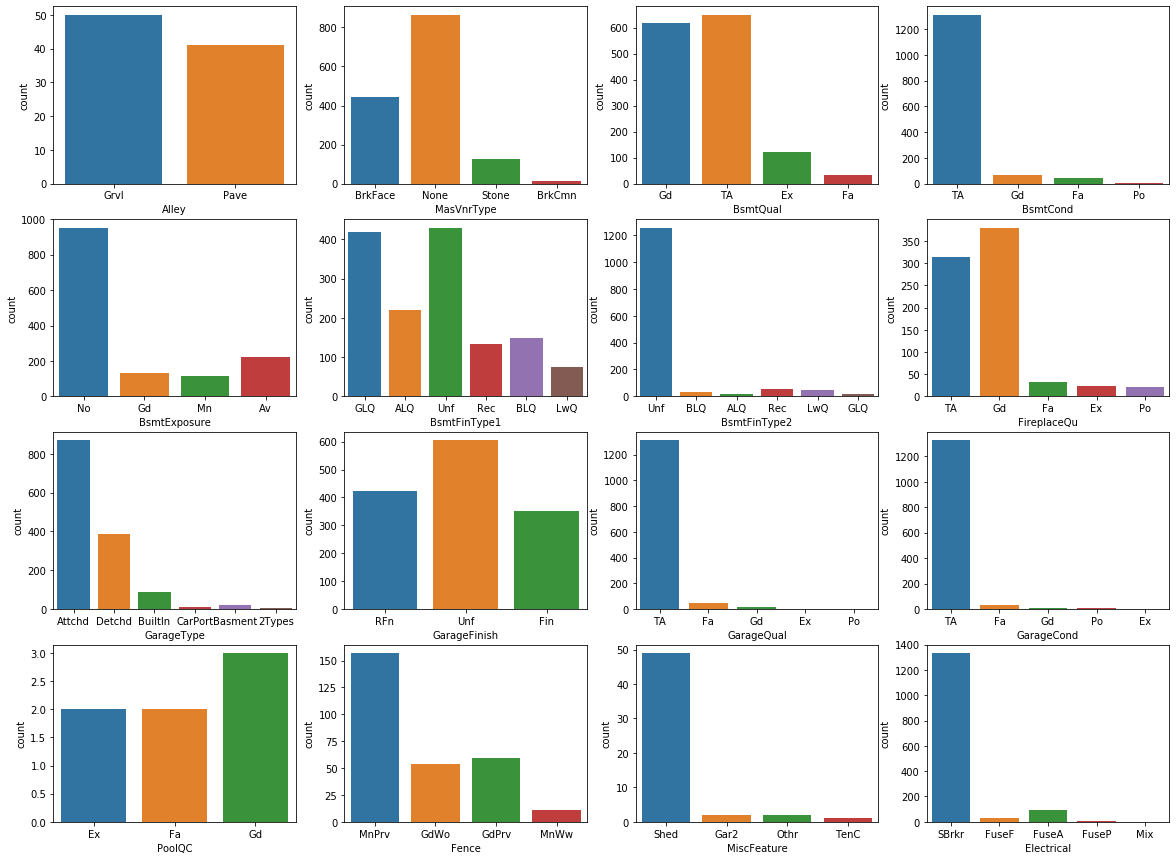

In [11]:
#Checking the categorical variables values and counts
plt.figure(figsize=(20,15))
plt.subplot(4,4,1)
sns.countplot(x="Alley", data=housingdata);
plt.subplot(4,4,2)
sns.countplot(x="MasVnrType", data=housingdata);
plt.subplot(4,4,3)
sns.countplot(x="BsmtQual", data=housingdata);
plt.subplot(4,4,4)
sns.countplot(x="BsmtCond", data=housingdata);
plt.subplot(4,4,5)
sns.countplot(x="BsmtExposure", data=housingdata);
plt.subplot(4,4,6)
sns.countplot(x="BsmtFinType1", data=housingdata);
plt.subplot(4,4,7)
sns.countplot(x="BsmtFinType2", data=housingdata);
plt.subplot(4,4,8)
sns.countplot(x="FireplaceQu", data=housingdata);
plt.subplot(4,4,9)
sns.countplot(x="GarageType", data=housingdata);
plt.subplot(4,4,10)
sns.countplot(x="GarageFinish", data=housingdata);
plt.subplot(4,4,11)
sns.countplot(x="GarageQual", data=housingdata);
plt.subplot(4,4,12)
sns.countplot(x="GarageCond", data=housingdata);
plt.subplot(4,4,13)
sns.countplot(x="PoolQC", data=housingdata);
plt.subplot(4,4,14)
sns.countplot(x="Fence", data=housingdata);
plt.subplot(4,4,15)
sns.countplot(x="MiscFeature", data=housingdata);
plt.subplot(4,4,16)
sns.countplot(x="Electrical", data=housingdata);
plt.show()

In [12]:
# identifying null values in all categorical columns
housingdata.select_dtypes(include='object').isnull().sum()[housingdata.select_dtypes(include='object').isnull().sum()>0]

Alley           1369
MasVnrType         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [13]:
# Replace NAN values with None values in the below columns : 

for col in ('Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'):
    
    housingdata[col]=housingdata[col].fillna('None')

In [14]:
# confirmng all the NA values are replaced with None.
housingdata.select_dtypes(include='object').isnull().sum()[housingdata.select_dtypes(include='object').isnull().sum()>0]

Series([], dtype: int64)

**As part of the data cleanup, we check if any categorical attribute that have more than 85% of data assosiated to one type of value. If so, then the information content of such variables in very less. We can consider to drop these variable thereby making our dataset is more manageble.**
- We will remove any column that has one value repeating 1241 times (1241/1450)*100 = 85%) as this column would be skewed
  to one value

In [15]:
# Here we drop the columns that have more than 85% values associated to a specific value type.
# In below method we get the column names that have count of one value more than 85% and drop such columns.

def get85PerCategoricalValueCounts():
    column = []
    categorical_columns = housingdata.select_dtypes(include=['object'])
    for col in (categorical_columns):
        if(housingdata[col].value_counts().max() >= 1241):
            column.append(col)
    return column

columnsToDrop = get85PerCategoricalValueCounts()

# Remove the columns with skewed data

housingdata.drop(columnsToDrop, axis = 1, inplace = True)

housingdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,BldgType,HouseStyle,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Reg,Inside,CollgCr,1Fam,2Story,...,0,0,0,0,None,0,2,2008,Normal,208500
1,2,20,RL,80.0,9600,Reg,FR2,Veenker,1Fam,1Story,...,0,0,0,0,None,0,5,2007,Normal,181500
2,3,60,RL,68.0,11250,IR1,Inside,CollgCr,1Fam,2Story,...,0,0,0,0,None,0,9,2008,Normal,223500
3,4,70,RL,60.0,9550,IR1,Corner,Crawfor,1Fam,2Story,...,272,0,0,0,None,0,2,2006,Abnorml,140000
4,5,60,RL,84.0,14260,IR1,FR2,NoRidge,1Fam,2Story,...,0,0,0,0,None,0,12,2008,Normal,250000


In [16]:
# Now we can see columns are reduced.
housingdata.shape

(1460, 60)

In [17]:
# Confirming again that the null values in all categorical columns are dropped.
housingdata.select_dtypes(include='object').isnull().sum()[housingdata.select_dtypes(include='object').isnull().sum()>0]

Series([], dtype: int64)

#### Cleaning Numerical variables by removing/imputing null values.

In [18]:
# Identifying the null values in the numerical data
housingdata.select_dtypes(include=['int64','float']).isnull().sum()[housingdata.select_dtypes(include=['int64','float']).isnull()
                                                                  .sum()>0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [19]:
# Impute the null values with median values for 'LotFrontage' and 'MasVnrArea' columns
housingdata['LotFrontage'] = housingdata['LotFrontage'].replace(np.nan, housingdata['LotFrontage'].median())
housingdata['MasVnrArea'] = housingdata['MasVnrArea'].replace(np.nan, housingdata['MasVnrArea'].median())

In [20]:
# Setting the null values with 0 for GarageYrBlt for now as we would be handling this column further below
housingdata['GarageYrBlt']=housingdata['GarageYrBlt'].fillna(0)
housingdata['GarageYrBlt'] = housingdata['GarageYrBlt'].astype(int)

In [21]:
# Create a new column named IsRemodelled - This column would determine whether the house has been remodelled or not based on 
# the difference between remodelled and built years

def isRemodel(row):
    if(row['YearBuilt'] == row['YearRemodAdd']):
        return 0
    elif(row['YearBuilt'] < row['YearRemodAdd']):
        return 1
    else:
        return 2
    
housingdata['IsRemodelled'] = housingdata.apply(isRemodel, axis=1)
housingdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,BldgType,HouseStyle,...,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleCondition,SalePrice,IsRemodelled
0,1,60,RL,65.0,8450,Reg,Inside,CollgCr,1Fam,2Story,...,0,0,0,None,0,2,2008,Normal,208500,0
1,2,20,RL,80.0,9600,Reg,FR2,Veenker,1Fam,1Story,...,0,0,0,None,0,5,2007,Normal,181500,0
2,3,60,RL,68.0,11250,IR1,Inside,CollgCr,1Fam,2Story,...,0,0,0,None,0,9,2008,Normal,223500,1
3,4,70,RL,60.0,9550,IR1,Corner,Crawfor,1Fam,2Story,...,0,0,0,None,0,2,2006,Abnorml,140000,1
4,5,60,RL,84.0,14260,IR1,FR2,NoRidge,1Fam,2Story,...,0,0,0,None,0,12,2008,Normal,250000,0


In [22]:
# derive a new column named BuiltOrRemodelledAge and identify the age of the building at the time of selling
def getBuiltOrRemodelAge(row):
    if(row['YearBuilt'] == row['YearRemodAdd']):
        return row['YrSold'] - row['YearBuilt']
    else:
        return row['YrSold'] - row['YearRemodAdd']
       
housingdata['BuiltOrRemodelAge'] = housingdata.apply(getBuiltOrRemodelAge, axis=1)
housingdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,BldgType,HouseStyle,...,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleCondition,SalePrice,IsRemodelled,BuiltOrRemodelAge
0,1,60,RL,65.0,8450,Reg,Inside,CollgCr,1Fam,2Story,...,0,0,None,0,2,2008,Normal,208500,0,5
1,2,20,RL,80.0,9600,Reg,FR2,Veenker,1Fam,1Story,...,0,0,None,0,5,2007,Normal,181500,0,31
2,3,60,RL,68.0,11250,IR1,Inside,CollgCr,1Fam,2Story,...,0,0,None,0,9,2008,Normal,223500,1,6
3,4,70,RL,60.0,9550,IR1,Corner,Crawfor,1Fam,2Story,...,0,0,None,0,2,2006,Abnorml,140000,1,36
4,5,60,RL,84.0,14260,IR1,FR2,NoRidge,1Fam,2Story,...,0,0,None,0,12,2008,Normal,250000,0,8


In [23]:
# Create a new column which would indicate if the Garage is old or new.
# Garage Yr Built less than 2000 will be considered as old (0) else new(1). 
# For GarageYrBuilt , where we have imputed the value as 0 will also be treated as old.

def getGarageConstPeriod(row):
    if row == 0:
        return 0
    elif row >= 1900 and row < 2000:        
        return 0
    else:   
        return 1
    
housingdata['OldOrNewGarage'] = housingdata['GarageYrBlt'].apply(getGarageConstPeriod)
housingdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,BldgType,HouseStyle,...,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleCondition,SalePrice,IsRemodelled,BuiltOrRemodelAge,OldOrNewGarage
0,1,60,RL,65.0,8450,Reg,Inside,CollgCr,1Fam,2Story,...,0,None,0,2,2008,Normal,208500,0,5,1
1,2,20,RL,80.0,9600,Reg,FR2,Veenker,1Fam,1Story,...,0,None,0,5,2007,Normal,181500,0,31,0
2,3,60,RL,68.0,11250,IR1,Inside,CollgCr,1Fam,2Story,...,0,None,0,9,2008,Normal,223500,1,6,1
3,4,70,RL,60.0,9550,IR1,Corner,Crawfor,1Fam,2Story,...,0,None,0,2,2006,Abnorml,140000,1,36,0
4,5,60,RL,84.0,14260,IR1,FR2,NoRidge,1Fam,2Story,...,0,None,0,12,2008,Normal,250000,0,8,1


In [24]:
# Since we have created new features from YearBuilt, YearRemodAdd, YrSold and GarageYrBlt, we can drop these columns as we 
# would only be using the derived columns for further analysis

housingdata.drop(['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt'], axis = 1, inplace = True)

In [25]:
# Drop the following columns that have more than 85% values associated to a specific value
# We will also drop MoSold as we will not be using that for further analysis

def getHighNumericalValueCounts():
    column = []
    numerical_columns = housingdata.select_dtypes(include=['int64', 'float'])
    for col in (numerical_columns):
        if(housingdata[col].value_counts().max() >= 1241):
            column.append(col)
    return column

columnsToBeRemoved = getHighNumericalValueCounts()
housingdata.drop(columnsToBeRemoved, axis = 1, inplace = True)

housingdata.drop(['MoSold'], axis = 1, inplace = True)

housingdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,BldgType,HouseStyle,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,Fence,SaleCondition,SalePrice,IsRemodelled,BuiltOrRemodelAge,OldOrNewGarage
0,1,60,RL,65.0,8450,Reg,Inside,CollgCr,1Fam,2Story,...,2,548,0,61,None,Normal,208500,0,5,1
1,2,20,RL,80.0,9600,Reg,FR2,Veenker,1Fam,1Story,...,2,460,298,0,None,Normal,181500,0,31,0
2,3,60,RL,68.0,11250,IR1,Inside,CollgCr,1Fam,2Story,...,2,608,0,42,None,Normal,223500,1,6,1
3,4,70,RL,60.0,9550,IR1,Corner,Crawfor,1Fam,2Story,...,3,642,0,35,None,Abnorml,140000,1,36,0
4,5,60,RL,84.0,14260,IR1,FR2,NoRidge,1Fam,2Story,...,3,836,192,84,None,Normal,250000,0,8,1


In [26]:
# check for percentage of null values in each column
percent_missing = round(100*(housingdata.isnull().sum()/len(housingdata.index)), 2)
print(percent_missing)

Id                   0.0
MSSubClass           0.0
MSZoning             0.0
LotFrontage          0.0
LotArea              0.0
LotShape             0.0
LotConfig            0.0
Neighborhood         0.0
BldgType             0.0
HouseStyle           0.0
OverallQual          0.0
OverallCond          0.0
RoofStyle            0.0
Exterior1st          0.0
Exterior2nd          0.0
MasVnrType           0.0
MasVnrArea           0.0
ExterQual            0.0
Foundation           0.0
BsmtQual             0.0
BsmtExposure         0.0
BsmtFinType1         0.0
BsmtFinSF1           0.0
BsmtUnfSF            0.0
TotalBsmtSF          0.0
HeatingQC            0.0
1stFlrSF             0.0
2ndFlrSF             0.0
GrLivArea            0.0
BsmtFullBath         0.0
FullBath             0.0
HalfBath             0.0
BedroomAbvGr         0.0
KitchenQual          0.0
TotRmsAbvGrd         0.0
Fireplaces           0.0
FireplaceQu          0.0
GarageType           0.0
GarageFinish         0.0
GarageCars           0.0


In [27]:
# Check for duplicates
housingdata[housingdata.duplicated(keep=False)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,BldgType,HouseStyle,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,Fence,SaleCondition,SalePrice,IsRemodelled,BuiltOrRemodelAge,OldOrNewGarage


#### Outlier Treatment

In [28]:
# Find outliers at 25%,50%,75%,90%,95% and above
housingdata.describe(percentiles=[.25,.5,.75,.90,.95,.99])

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,...,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,SalePrice,IsRemodelled,BuiltOrRemodelAge,OldOrNewGarage
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,69.863699,10516.828082,6.099315,5.575342,103.117123,443.639726,567.240411,1057.429452,...,6.517808,0.613014,1.767123,472.980137,94.244521,46.660274,180921.195890,0.476712,22.950000,0.275342
std,421.610009,42.300571,22.027677,9981.264932,1.382997,1.112799,180.731373,456.098091,441.866955,438.705324,...,1.625393,0.644666,0.747315,213.804841,125.338794,66.256028,79442.502883,0.499629,20.640653,0.446840
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34900.000000,0.000000,-1.000000,0.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,0.000000,0.000000,223.000000,795.750000,...,5.000000,0.000000,1.000000,334.500000,0.000000,0.000000,129975.000000,0.000000,4.000000,0.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,0.000000,383.500000,477.500000,991.500000,...,6.000000,1.000000,2.000000,480.000000,0.000000,25.000000,163000.000000,0.000000,14.000000,0.000000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,164.250000,712.250000,808.000000,1298.250000,...,7.000000,1.000000,2.000000,576.000000,168.000000,68.000000,214000.000000,1.000000,41.000000,1.000000
90%,1314.100000,120.000000,92.000000,14381.700000,8.000000,7.000000,335.000000,1065.500000,1232.000000,1602.200000,...,9.000000,1.000000,3.000000,757.100000,262.000000,130.000000,278000.000000,1.000000,56.000000,1.000000
95%,1387.050000,160.000000,104.000000,17401.150000,8.000000,8.000000,456.000000,1274.000000,1468.000000,1753.000000,...,10.000000,2.000000,3.000000,850.100000,335.000000,175.050000,326100.000000,1.000000,58.000000,1.000000
99%,1445.410000,190.000000,137.410000,37567.640000,10.000000,9.000000,791.280000,1572.410000,1797.050000,2155.050000,...,11.000000,2.000000,3.000000,1002.790000,505.460000,285.820000,442567.010000,1.000000,60.000000,1.000000


***As we notice the 50% and mean values for the 'LotArea', 'MasVnrArea', 'TotalBsmtSF', 'WoodDeckSF' and 'OpenPorchSF'  variables are significant and these are few variables with outliers.***

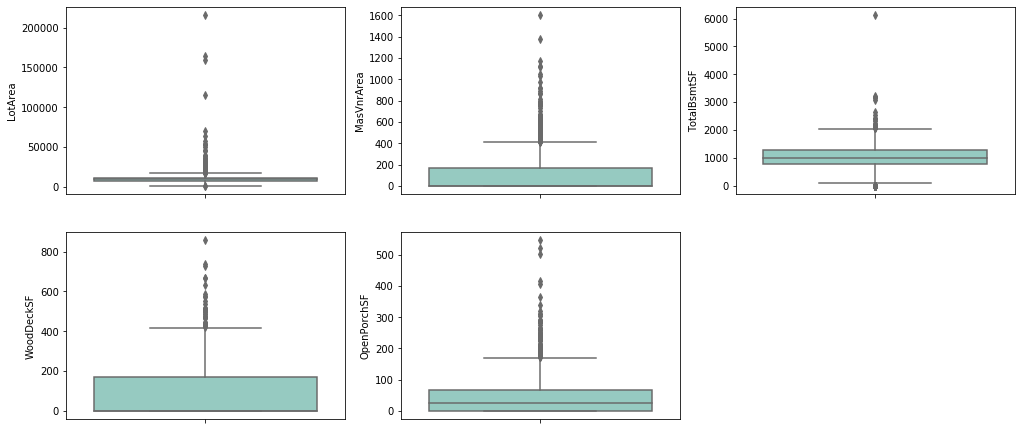

In [29]:
# Visualizing the outliers in all the numeric columns through the boxplot.
plt.figure(figsize=(17, 20))
plt.subplot(5,3,1)
sns.boxplot(y = 'LotArea', palette='Set3', data = housingdata)
plt.subplot(5,3,2)
sns.boxplot(y = 'MasVnrArea', palette='Set3', data = housingdata)
plt.subplot(5,3,3)
sns.boxplot(y = 'TotalBsmtSF', palette='Set3', data = housingdata)
plt.subplot(5,3,4)
sns.boxplot(y = 'WoodDeckSF', palette='Set3', data = housingdata)
plt.subplot(5,3,5)
sns.boxplot(y = 'OpenPorchSF', palette='Set3', data = housingdata)
plt.show()

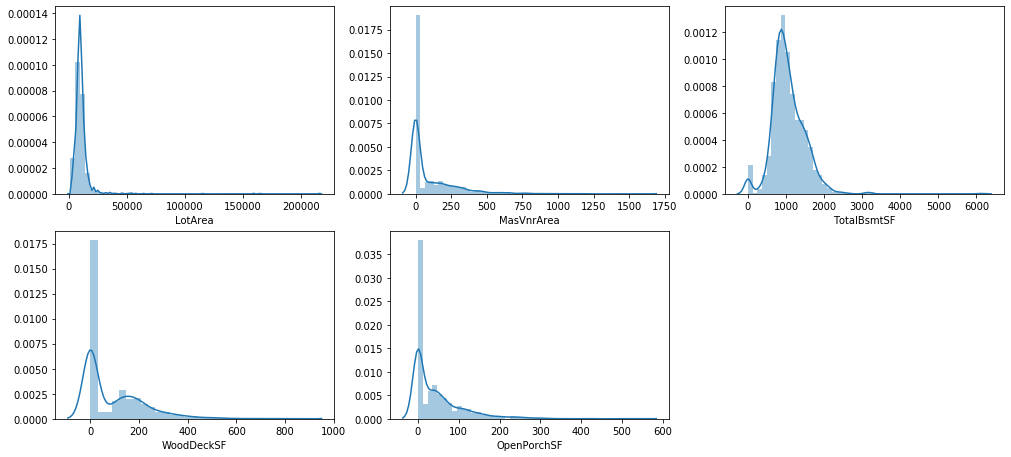

In [30]:
# Visualizing the outliers in all the numeric columns through the distplot.
plt.figure(figsize=(17, 20))
plt.subplot(5,3,1)

sns.distplot(housingdata['LotArea'])
plt.subplot(5,3,2)
sns.distplot(housingdata['MasVnrArea'])
plt.subplot(5,3,3)
sns.distplot(housingdata['TotalBsmtSF'])
plt.subplot(5,3,4)
sns.distplot(housingdata['WoodDeckSF'])
plt.subplot(5,3,5)
sns.distplot(housingdata['OpenPorchSF'])
plt.show()

In [31]:
# Removing Outliers
# Removing values beyond 98% for LotArea
nn_quartile_LotArea = housingdata['LotArea'].quantile(0.98)
housingdata = housingdata[housingdata["LotArea"] < nn_quartile_LotArea]

# Removing values beyond 98% for MasVnrArea

nn_quartile_MasVnrArea = housingdata['MasVnrArea'].quantile(0.98)
housingdata = housingdata[housingdata["MasVnrArea"] < nn_quartile_MasVnrArea]

# Removing values beyond 99% for TotalBsmtSF

nn_quartile_TotalBsmtSF = housingdata['TotalBsmtSF'].quantile(0.99)
housingdata = housingdata[housingdata["TotalBsmtSF"] < nn_quartile_TotalBsmtSF]

# Removing values beyond 99% for WoodDeckSF

nn_quartile_WoodDeckSF = housingdata['WoodDeckSF'].quantile(0.99)
housingdata = housingdata[housingdata["WoodDeckSF"] < nn_quartile_WoodDeckSF]

# Removing values beyond 99% for OpenPorchSF

nn_quartile_OpenPorchSF = housingdata['OpenPorchSF'].quantile(0.99)
housingdata = housingdata[housingdata["OpenPorchSF"] < nn_quartile_OpenPorchSF]

In [32]:
# Calculate the percentage of data retained
num_data = round(100*(len(housingdata)/1460),2)
print(num_data)

93.01


### 3: Data Visualization

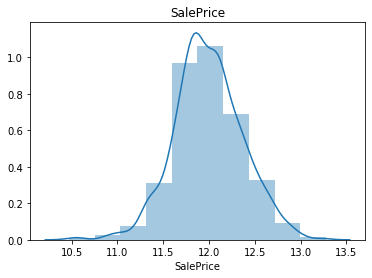

In [33]:
# Target variable visualization, by transforming the SalesPrice on log scale.
housingdata['SalePrice'] = np.log1p(housingdata['SalePrice'])
plt.title('SalePrice')
sns.distplot(housingdata['SalePrice'], bins=10)
plt.show()

The target value (SalesPrice) appears to be normally distributed with few noise.

<Figure size 720x360 with 0 Axes>

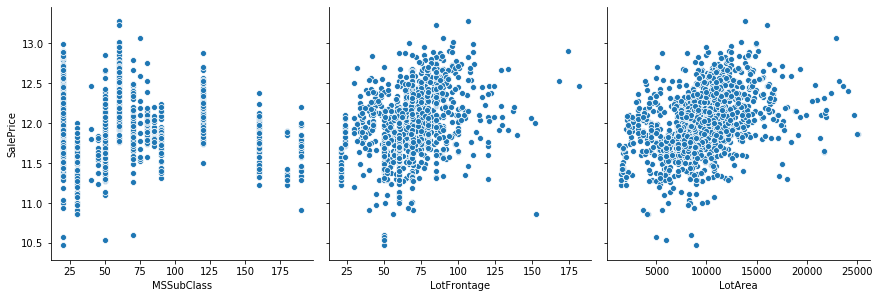

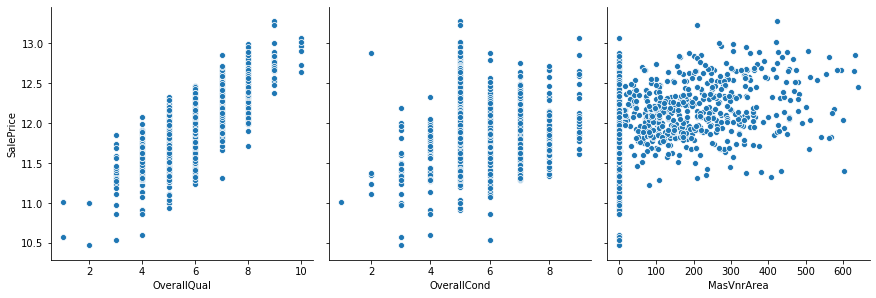

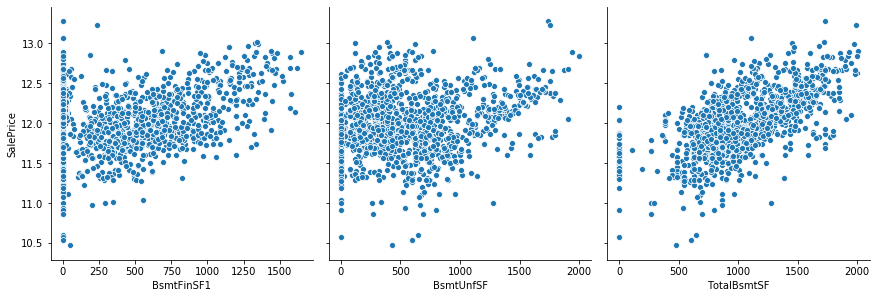

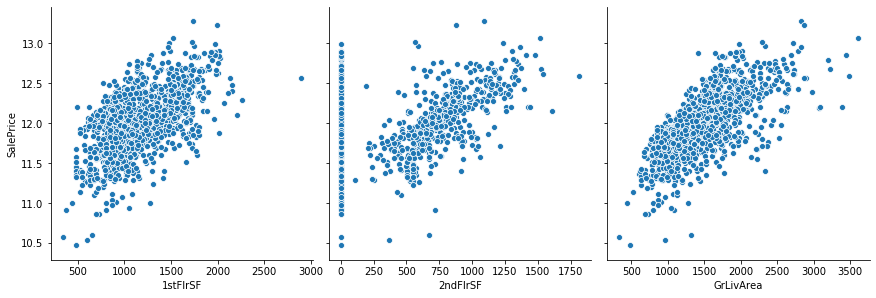

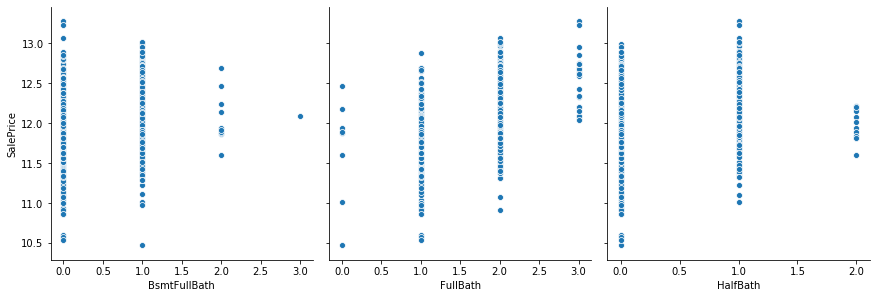

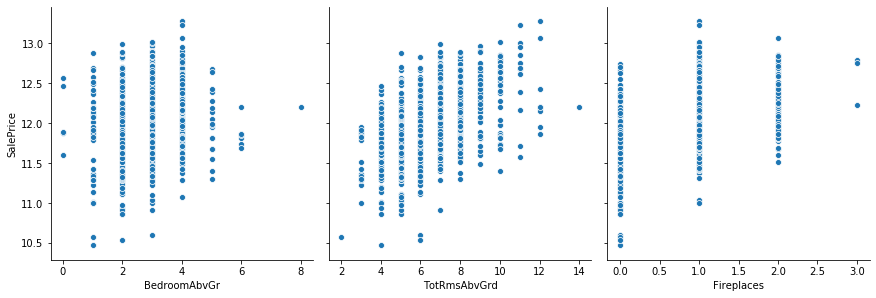

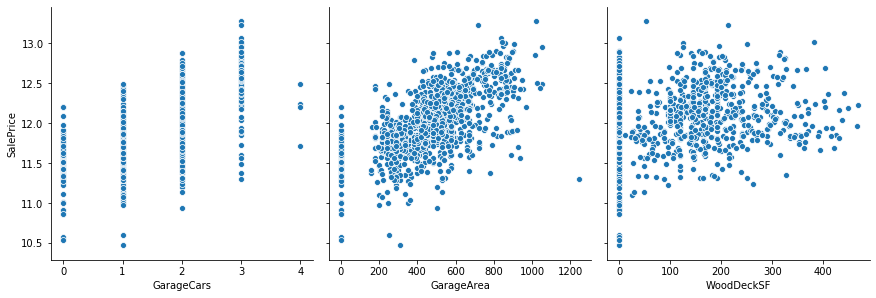

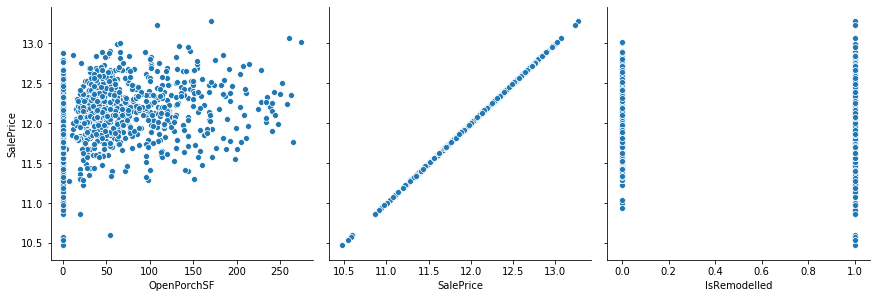

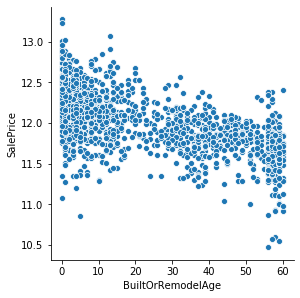

In [34]:
# Checking numerical variables through pairplots.

plt.figure(figsize=(10,5))
sns.pairplot(housingdata, x_vars=['MSSubClass','LotFrontage','LotArea'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['OverallQual', 'OverallCond','MasVnrArea'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['BsmtFinSF1', 'BsmtUnfSF','TotalBsmtSF'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['1stFlrSF','2ndFlrSF', 'GrLivArea'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['BsmtFullBath','FullBath', 'HalfBath'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['BedroomAbvGr','TotRmsAbvGrd', 'Fireplaces'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['GarageCars','GarageArea', 'WoodDeckSF'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['OpenPorchSF','SalePrice', 'IsRemodelled'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
sns.pairplot(housingdata, x_vars=['BuiltOrRemodelAge'], y_vars='SalePrice',height=4, aspect=1,kind='scatter')
plt.show()

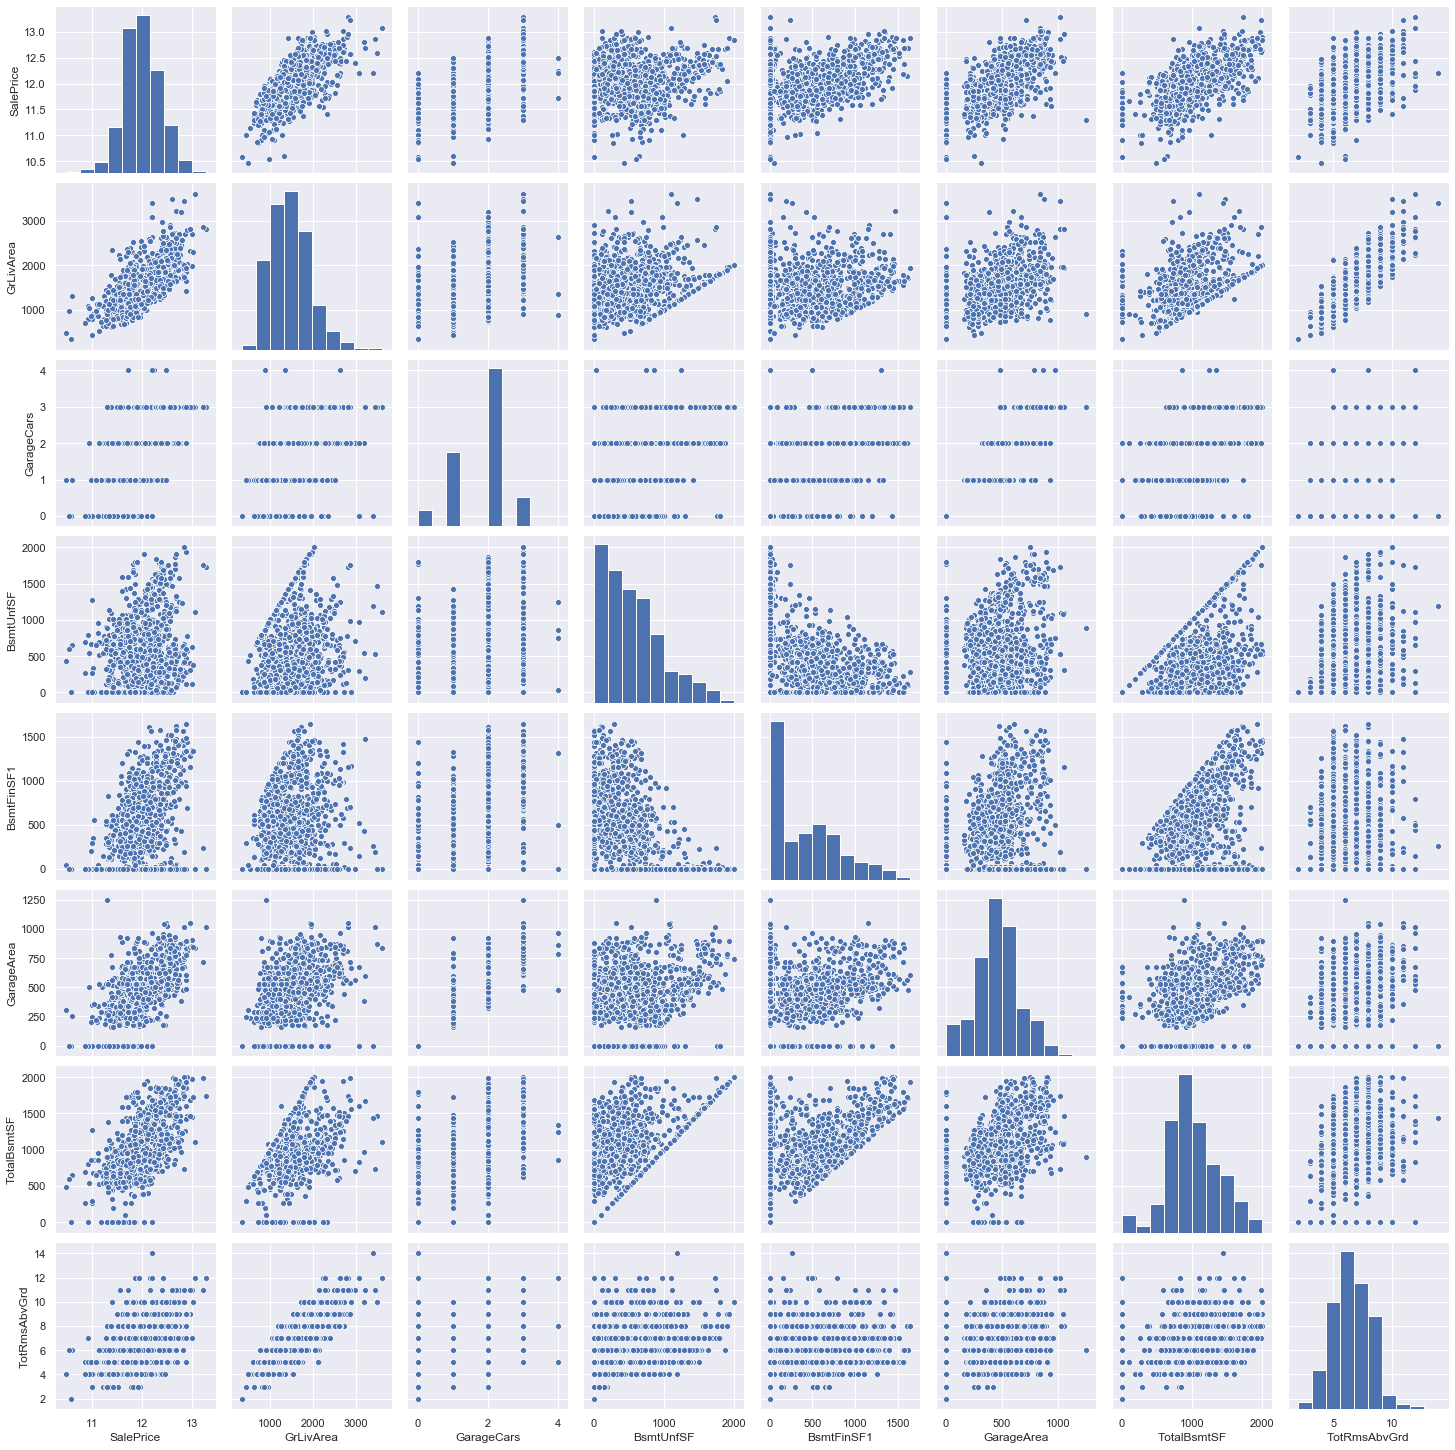

In [35]:
sns.set() 
cols = ['SalePrice', 'GrLivArea', 'GarageCars', 'BsmtUnfSF', 'BsmtFinSF1', 'GarageArea', 'TotalBsmtSF', 'TotRmsAbvGrd'] 
sns.pairplot(housingdata[cols], size = 2.5) 
plt.show()

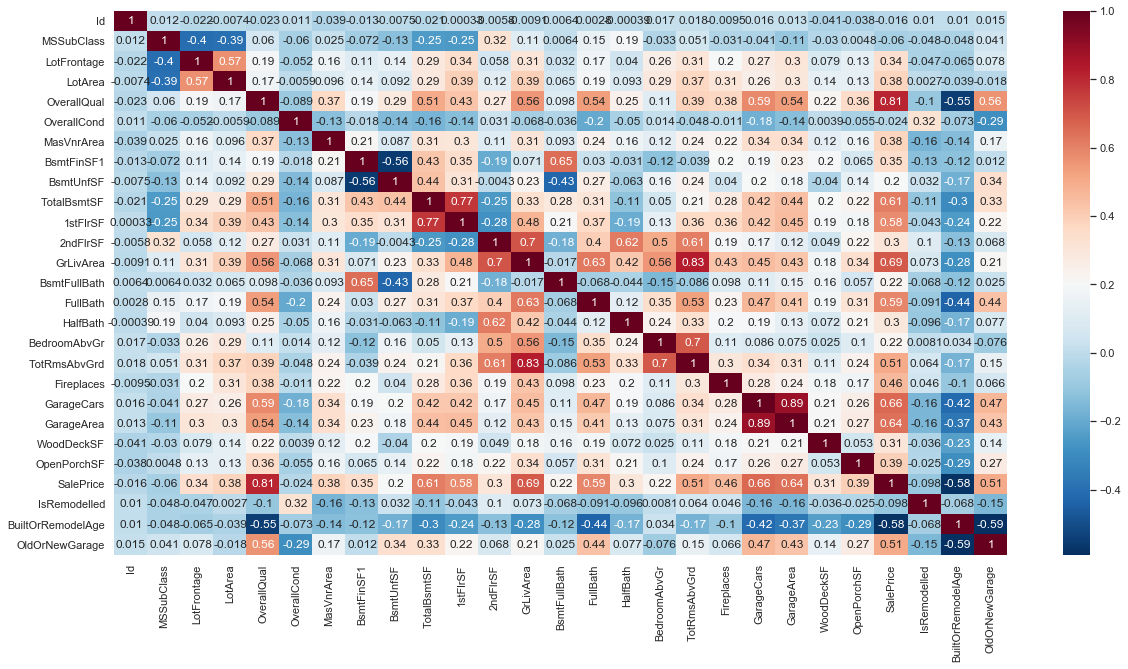

In [36]:
# Determine the correlation of numerical columns
plt.figure(figsize = (20, 10))
sns.heatmap(housingdata.corr(), annot = True, cmap="RdBu_r")
plt.show()

**Next, drop the columns which are highly correlated, to avoid multi colinearity.**
- Garage Area and Garage Cars show 89%
- TotRmsAbvGrd and GrLivArea show 83%

Hence we are dropping 'TotRmsAbvGrd' and 'Garage Cars' columns from the dataset.

In [37]:
# Dropping the highly correlated variables.
housingdata.drop(['TotRmsAbvGrd', 'GarageArea'], axis = 1, inplace = True)

In [38]:
# Check the shape of the dataframe
housingdata.shape

(1358, 47)

### 4: Data Preparation

**Let's assign ordered sequence value for ordered variables and for non ordered categorize them into  0 and 1.**

In [39]:
housingdata['d_LotShape'] = housingdata['LotShape'].map({'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0})
housingdata['d_LotShape'].value_counts()

3    880
2    441
1     29
0      8
Name: d_LotShape, dtype: int64

In [40]:
housingdata['d_ExterQual'] = housingdata['ExterQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0 })
housingdata['d_ExterQual'].value_counts()

3    864
4    448
5     32
2     14
Name: d_ExterQual, dtype: int64

In [41]:
housingdata['d_BsmtQual'] = housingdata['BsmtQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
housingdata['d_BsmtQual'].value_counts()

3    617
4    575
5     94
0     37
2     35
Name: d_BsmtQual, dtype: int64

In [42]:
housingdata['d_BsmtExposure'] = housingdata['BsmtExposure'].map({'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0})
housingdata['d_BsmtExposure'].value_counts()

1    906
3    208
2    104
4    102
0     38
Name: d_BsmtExposure, dtype: int64

In [43]:
housingdata['d_BsmtFinType1'] = housingdata['BsmtFinType1'].map({'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0})
housingdata['d_BsmtFinType1'].value_counts()

1    410
6    377
5    202
4    140
3    123
2     69
0     37
Name: d_BsmtFinType1, dtype: int64

In [44]:
housingdata['d_HeatingQC'] = housingdata['HeatingQC'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
housingdata['d_HeatingQC'].value_counts()

5    681
3    403
4    228
2     45
1      1
Name: d_HeatingQC, dtype: int64

In [45]:
housingdata['d_KitchenQual'] = housingdata['KitchenQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
housingdata['d_KitchenQual'].value_counts()

3    696
4    547
5     76
2     39
Name: d_KitchenQual, dtype: int64

In [46]:
housingdata['d_FireplaceQu'] = housingdata['FireplaceQu'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0})
housingdata['d_FireplaceQu'].value_counts()

0    672
4    337
3    284
2     31
1     19
5     15
Name: d_FireplaceQu, dtype: int64

In [47]:
housingdata['d_GarageFinish'] = housingdata['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0 })
housingdata['d_GarageFinish'].value_counts()

1    581
2    397
3    301
0     79
Name: d_GarageFinish, dtype: int64

In [48]:
housingdata['d_BldgType'] = housingdata['BldgType'].map({'Twnhs': 5, 'TwnhsE': 4, 'Duplex': 3, '2fmCon': 2, '1Fam': 1, 'None': 0 })
housingdata['d_BldgType'].value_counts()

1    1129
4     107
3      52
5      43
2      27
Name: d_BldgType, dtype: int64

In [49]:
housingdata['d_HouseStyle'] = housingdata['HouseStyle'].map({'SLvl': 8, 'SFoyer': 7, '2.5Fin': 6, '2.5Unf': 5, '2Story': 4, '1.5Fin': 3, '1.5Unf': 2, '1Story': 1, 'None': 0 })
housingdata['d_HouseStyle'].value_counts()

1    673
4    406
3    149
8     63
7     37
2     14
6      8
5      8
Name: d_HouseStyle, dtype: int64

In [50]:
housingdata['d_Fence'] = housingdata['Fence'].map({'GdPrv': 4, 'GdWo': 3, 'MnPrv': 2, 'MnWw': 1, 'None': 0 })
housingdata['d_Fence'].value_counts()

0    1093
2     152
4      52
3      51
1      10
Name: d_Fence, dtype: int64

In [51]:
housingdata['d_LotConfig'] = housingdata['LotConfig'].map({'Inside': 5, 'Corner': 4, 'CulDSac': 3, 'FR2': 2, 'FR3': 1, 'None': 0  })
housingdata['d_LotConfig'].value_counts()

5    988
4    244
3     78
2     44
1      4
Name: d_LotConfig, dtype: int64

In [52]:
housingdata['d_MasVnrType'] = housingdata['MasVnrType'].map({'BrkCmn': 1, 'BrkFace': 1, 'CBlock': 1, 'Stone': 1, 'None': 0 })
housingdata['d_MasVnrType'].value_counts()

0    828
1    530
Name: d_MasVnrType, dtype: int64

In [53]:
housingdata['d_SaleCondition'] = housingdata['SaleCondition'].map({'Normal': 1, 'Partial': 1, 'Abnorml': 0, 'Family': 0, 'Alloca': 0, 'AdjLand': 0, 'None': 0})
housingdata['d_SaleCondition'].value_counts()

1    1229
0     129
Name: d_SaleCondition, dtype: int64

In [54]:
housingdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,BldgType,HouseStyle,...,d_HeatingQC,d_KitchenQual,d_FireplaceQu,d_GarageFinish,d_BldgType,d_HouseStyle,d_Fence,d_LotConfig,d_MasVnrType,d_SaleCondition
0,1,60,RL,65.0,8450,Reg,Inside,CollgCr,1Fam,2Story,...,5,4,0,2,1,4,0,5,1,1
1,2,20,RL,80.0,9600,Reg,FR2,Veenker,1Fam,1Story,...,5,3,3,2,1,1,0,2,0,1
2,3,60,RL,68.0,11250,IR1,Inside,CollgCr,1Fam,2Story,...,5,4,3,2,1,4,0,5,1,1
3,4,70,RL,60.0,9550,IR1,Corner,Crawfor,1Fam,2Story,...,4,4,4,1,1,4,0,4,0,0
4,5,60,RL,84.0,14260,IR1,FR2,NoRidge,1Fam,2Story,...,5,4,3,2,1,4,0,2,1,1


In [55]:
# We need to drop the columns for which we have derived new columns. As well dropping 'Id', since its not used.
housingdata = housingdata.drop(['Id', 'LotShape', 'ExterQual', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 
                                'KitchenQual', 'FireplaceQu', 'GarageFinish', 'BldgType', 'HouseStyle', 'Fence', 
                                'LotConfig', 'MasVnrType', 'SaleCondition'], axis=1)

housingdata.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,RoofStyle,Exterior1st,Exterior2nd,...,d_HeatingQC,d_KitchenQual,d_FireplaceQu,d_GarageFinish,d_BldgType,d_HouseStyle,d_Fence,d_LotConfig,d_MasVnrType,d_SaleCondition
0,60,RL,65.0,8450,CollgCr,7,5,Gable,VinylSd,VinylSd,...,5,4,0,2,1,4,0,5,1,1
1,20,RL,80.0,9600,Veenker,6,8,Gable,MetalSd,MetalSd,...,5,3,3,2,1,1,0,2,0,1
2,60,RL,68.0,11250,CollgCr,7,5,Gable,VinylSd,VinylSd,...,5,4,3,2,1,4,0,5,1,1
3,70,RL,60.0,9550,Crawfor,7,5,Gable,Wd Sdng,Wd Shng,...,4,4,4,1,1,4,0,4,0,0
4,60,RL,84.0,14260,NoRidge,8,5,Gable,VinylSd,VinylSd,...,5,4,3,2,1,4,0,2,1,1


In [56]:
# Creating dummy variables for 'MSZoning', 'Neighborhood', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'Foundation' and 'GarageType' columns.
d_MSZoning = pd.get_dummies(housingdata['MSZoning'], prefix='MSZoning', drop_first = True)
housingdata = pd.concat([housingdata, d_MSZoning], axis = 1)

d_Neighborhood = pd.get_dummies(housingdata['Neighborhood'], prefix='Neighborhood', drop_first = True)
housingdata = pd.concat([housingdata, d_Neighborhood], axis = 1)

d_RoofStyle = pd.get_dummies(housingdata['RoofStyle'], prefix='RoofStyle', drop_first = True)
housingdata = pd.concat([housingdata, d_RoofStyle], axis = 1)

d_Exterior1st = pd.get_dummies(housingdata['Exterior1st'], prefix='Exterior1st', drop_first = True)
housingdata = pd.concat([housingdata, d_Exterior1st], axis = 1)

d_Exterior2nd = pd.get_dummies(housingdata['Exterior2nd'], prefix='Exterior2nd', drop_first = True)
housingdata = pd.concat([housingdata, d_Exterior2nd], axis = 1)

d_Foundation = pd.get_dummies(housingdata['Foundation'], prefix='Foundation', drop_first = True)
housingdata = pd.concat([housingdata, d_Foundation], axis = 1)

d_GarageType = pd.get_dummies(housingdata['GarageType'], prefix='GarageType', drop_first = True)
housingdata = pd.concat([housingdata, d_GarageType], axis = 1)

housingdata.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,RoofStyle,Exterior1st,Exterior2nd,...,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None
0,60,RL,65.0,8450,CollgCr,7,5,Gable,VinylSd,VinylSd,...,1,0,0,0,1,0,0,0,0,0
1,20,RL,80.0,9600,Veenker,6,8,Gable,MetalSd,MetalSd,...,0,0,0,0,1,0,0,0,0,0
2,60,RL,68.0,11250,CollgCr,7,5,Gable,VinylSd,VinylSd,...,1,0,0,0,1,0,0,0,0,0
3,70,RL,60.0,9550,Crawfor,7,5,Gable,Wd Sdng,Wd Shng,...,0,0,0,0,0,0,0,0,1,0
4,60,RL,84.0,14260,NoRidge,8,5,Gable,VinylSd,VinylSd,...,1,0,0,0,1,0,0,0,0,0


In [57]:
# Since we have derived dummy columns for 'MSZoning', 'Neighborhood', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'Foundation', 'GarageType' columns.
# Let's drop these columns from dataset.
housingdata = housingdata.drop(['MSZoning', 'Neighborhood', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'Foundation', 'GarageType'], axis=1)

In [58]:
housingdata.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None
0,60,65.0,8450,7,5,196.0,706,150,856,856,...,1,0,0,0,1,0,0,0,0,0
1,20,80.0,9600,6,8,0.0,978,284,1262,1262,...,0,0,0,0,1,0,0,0,0,0
2,60,68.0,11250,7,5,162.0,486,434,920,920,...,1,0,0,0,1,0,0,0,0,0
3,70,60.0,9550,7,5,0.0,216,540,756,961,...,0,0,0,0,0,0,0,0,1,0
4,60,84.0,14260,8,5,350.0,655,490,1145,1145,...,1,0,0,0,1,0,0,0,0,0


In [59]:
housingdata.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1358 entries, 0 to 1458
Columns: 112 entries, MSSubClass to GarageType_None
dtypes: float64(3), int64(36), uint8(73)
memory usage: 561.2 KB


In [60]:
housingdata.shape

(1358, 112)

### 5: Train Test Split

***Let's create Train and Test datasets in X and y variables.***

In [61]:
# Retriving all features variables in to X.
X = housingdata.drop(['SalePrice'], axis=1)
X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None
0,60,65.0,8450,7,5,196.0,706,150,856,856,...,1,0,0,0,1,0,0,0,0,0
1,20,80.0,9600,6,8,0.0,978,284,1262,1262,...,0,0,0,0,1,0,0,0,0,0
2,60,68.0,11250,7,5,162.0,486,434,920,920,...,1,0,0,0,1,0,0,0,0,0
3,70,60.0,9550,7,5,0.0,216,540,756,961,...,0,0,0,0,0,0,0,0,1,0
4,60,84.0,14260,8,5,350.0,655,490,1145,1145,...,1,0,0,0,1,0,0,0,0,0


In [62]:
# Retriving response variables in to y.
y = housingdata['SalePrice']
y.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64

In [63]:
X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None
0,60,65.0,8450,7,5,196.0,706,150,856,856,...,1,0,0,0,1,0,0,0,0,0
1,20,80.0,9600,6,8,0.0,978,284,1262,1262,...,0,0,0,0,1,0,0,0,0,0
2,60,68.0,11250,7,5,162.0,486,434,920,920,...,1,0,0,0,1,0,0,0,0,0
3,70,60.0,9550,7,5,0.0,216,540,756,961,...,0,0,0,0,0,0,0,0,1,0
4,60,84.0,14260,8,5,350.0,655,490,1145,1145,...,1,0,0,0,1,0,0,0,0,0


#### Rescaling the features.

It is very important to rescale the variables so that they have a comparable scale. If we don't have comparable scales, then some of the coefficients as obtained by fitting the regression model might be very large or very small as compared to the other coefficients. This might become issue at the time of model evaluation, so it is recommonded to use standardization or normalization so that the units of the coefficients obtained are all on the same scale.

In [64]:
# storing column names in cols
# scaling (the dataframe is converted to a numpy array)
# # Apply scaler() to rescale all the numerical columns (features) except the 'dummy' variables.

cols = X.columns
X = pd.DataFrame(scale(X))
X.columns = cols
X.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       ...
       'Foundation_PConc', 'Foundation_Slab', 'Foundation_Stone',
       'Foundation_Wood', 'GarageType_Attchd', 'GarageType_Basment',
       'GarageType_BuiltIn', 'GarageType_CarPort', 'GarageType_Detchd',
       'GarageType_None'],
      dtype='object', length=111)

In [65]:
X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None
0,0.067234,-0.194211,-0.272474,0.740183,-0.526853,0.836649,0.707340,-0.950680,-0.428337,-0.798154,...,1.142630,-0.134131,-0.060791,-0.047053,0.840256,-0.119121,-0.245172,-0.08168,-0.616507,-0.24853
1,-0.878923,0.578157,0.045661,-0.017863,2.149454,-0.625900,1.370251,-0.638366,0.646811,0.395671,...,-0.875174,-0.134131,-0.060791,-0.047053,0.840256,-0.119121,-0.245172,-0.08168,-0.616507,-0.24853
2,0.067234,-0.039737,0.502115,0.740183,-0.526853,0.582942,0.171162,-0.288761,-0.258855,-0.609965,...,1.142630,-0.134131,-0.060791,-0.047053,0.840256,-0.119121,-0.245172,-0.08168,-0.616507,-0.24853
3,0.303774,-0.451667,0.031829,0.740183,-0.526853,-0.625900,-0.486874,-0.041707,-0.693151,-0.489406,...,-0.875174,-0.134131,-0.060791,-0.047053,-1.190113,-0.119121,-0.245172,-0.08168,1.622041,-0.24853
4,0.067234,0.784122,1.334799,1.498229,-0.526853,1.985796,0.583044,-0.158242,0.336977,0.051638,...,1.142630,-0.134131,-0.060791,-0.047053,0.840256,-0.119121,-0.245172,-0.08168,-0.616507,-0.24853


In [66]:
#Let's split the datasets into train and test data.
np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size = 0.3, random_state=42)

### 6: Recursive feature elimination (RFE)

In [67]:
# Creating LinearRegression object and fitting X_train & y_train
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [68]:
# Executing RFE with the output number of the variable equal to 50
rfe = RFE(lm, 50)            
rfe = rfe.fit(X_train, y_train)

In [69]:
# Let's start with the columns shortlisted by RFE, assigning the columns selected by RFE to cols.
col = X_train.columns[rfe.support_]

In [70]:
# assign the 50 features selected using RFE to a dataframe.
temp_df = pd.DataFrame(list(zip(X_train.columns,rfe.support_,rfe.ranking_)), columns=['Variable', 'rfe_support', 'rfe_ranking'])
temp_df = temp_df.loc[temp_df['rfe_support'] == True]
temp_df.reset_index(drop=True, inplace=True)

temp_df

,Variable,rfe_support,rfe_ranking
0,MSSubClass,True,1
1,LotArea,True,1
2,OverallQual,True,1
3,OverallCond,True,1
4,BsmtFinSF1,True,1
5,TotalBsmtSF,True,1
6,1stFlrSF,True,1
7,2ndFlrSF,True,1
8,GrLivArea,True,1
9,BsmtFullBath,True,1


In [71]:
# Assign the 50 columns to X_train_rfe
X_train_rfe = X_train[col]

In [72]:
# Associate the new 50 columns to X_train and X_test for further analysis
X_train = X_train_rfe[X_train_rfe.columns]
X_test =  X_test[X_train.columns]

### 7: Model Building and Evaluation

#####  L2 (Ridge) Regularisation

<b>In sklearn.linear_model.LogisticRegression, C actually refers to the inverse regularization strength, 𝟏/λ 
- Interpretation: 
- C is high, lambda is low, less regularisation. Model is complex and will overfit
- C is low, lambda is high, high regularisation. Model is simple and will underfit</b>


In [73]:

params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 
                    9.0, 10.0, 20, 50, 100, 500, 1000 ]}

ridge = Ridge()

# cross validation

folds = 5
ridge_model_cv = GridSearchCV(estimator = ridge, 
                        param_grid = params, 
                        scoring= 'neg_mean_absolute_error', 
                        cv = folds, 
                        return_train_score=True,
                        verbose = 1)            
ridge_model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 135 out of 135 | elapsed:    0.8s finished


GridSearchCV(cv=5, error_score=nan,
             estimator=Ridge(alpha=1.0, copy_X=True, fit_intercept=True,
                             max_iter=None, normalize=False, random_state=None,
                             solver='auto', tol=0.001),
             iid='deprecated', n_jobs=None,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5,
                                   0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0,
                                   6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500,
                                   1000]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='neg_mean_absolute_error', verbose=1)

In [74]:
ridge_model_cv.cv_results_

{'mean_fit_time': array([0.00479956, 0.00499921, 0.00419998, 0.00359979, 0.00460038,
        0.00439906, 0.00420041, 0.00319986, 0.00380039, 0.00359998,
        0.00280004, 0.00400052, 0.00340047, 0.00339966, 0.00320063,
        0.00299873, 0.00399928, 0.00300055, 0.00279984, 0.00259957,
        0.00279927, 0.00279989, 0.00319939, 0.00260043, 0.00279956,
        0.00260005, 0.0023993 ]),
 'std_fit_time': array([7.49081724e-04, 1.09606311e-03, 7.49095893e-04, 8.01338678e-04,
        4.93075852e-04, 4.89299405e-04, 7.50580666e-04, 4.01356116e-04,
        9.79474931e-04, 4.90837781e-04, 4.00328817e-04, 6.32711569e-04,
        8.00181835e-04, 7.99632959e-04, 3.98235502e-04, 2.24468275e-06,
        6.32712086e-04, 1.58436277e-06, 4.01545208e-04, 4.90935074e-04,
        4.01259871e-04, 4.00853366e-04, 3.99685105e-04, 4.89979428e-04,
        4.00209668e-04, 4.89668408e-04, 4.89512828e-04]),
 'mean_score_time': array([0.00179939, 0.0016026 , 0.00179935, 0.00119944, 0.00179853,
        0.001601

In [75]:
# display the mean scores
ridge_cv_results = pd.DataFrame(ridge_model_cv.cv_results_)
ridge_cv_results = ridge_cv_results[ridge_cv_results['param_alpha']<=100]
ridge_cv_results[['param_alpha', 'mean_train_score', 'mean_test_score', 'rank_test_score']].sort_values(by = ['rank_test_score'])

,param_alpha,mean_train_score,mean_test_score,rank_test_score
21,10,-0.078199,-0.084210,1
20,9,-0.078155,-0.084216,2
19,8,-0.078110,-0.084221,3
18,7,-0.078065,-0.084226,4
17,6,-0.078021,-0.084230,5
22,20,-0.078536,-0.084237,6
16,5,-0.077980,-0.084269,7
15,4,-0.077942,-0.084338,8
14,3,-0.077905,-0.084421,9
23,50,-0.079120,-0.084479,10


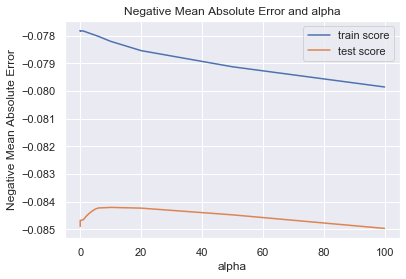

In [76]:
# plotting mean test and train scoes with alpha 
ridge_cv_results['param_alpha'] = ridge_cv_results['param_alpha'].astype('int32')

# plotting
plt.plot(ridge_cv_results['param_alpha'], ridge_cv_results['mean_train_score'])
plt.plot(ridge_cv_results['param_alpha'], ridge_cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative Mean Absolute Error')
plt.title("Negative Mean Absolute Error and alpha")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

In [77]:
# get the best estimator for lambda
ridge_model_cv.best_estimator_

Ridge(alpha=10.0, copy_X=True, fit_intercept=True, max_iter=None,
      normalize=False, random_state=None, solver='auto', tol=0.001)

In [78]:
# check the coefficient values with lambda = 10

alpha = 10
ridge = Ridge(alpha=alpha)

ridge.fit(X_train, y_train)
ridge.coef_

array([-0.00939379,  0.02195883,  0.06836313,  0.04504004,  0.03283145,
        0.04622329,  0.02473729,  0.02464272,  0.07905787,  0.01033503,
        0.01605522,  0.02132515,  0.03547342,  0.01020595, -0.01242812,
       -0.01939627,  0.01483745,  0.01386043,  0.01541266,  0.01864798,
        0.01617949,  0.0159313 , -0.01060815,  0.00635291,  0.01553711,
        0.05940973,  0.02242101,  0.08771411,  0.05804592,  0.0255173 ,
       -0.01102408, -0.00876949,  0.02236278, -0.01326178, -0.00895594,
        0.0168362 , -0.00969267, -0.00198895,  0.01391614, -0.03291536,
       -0.03058367, -0.00198895, -0.01828222,  0.02837442,  0.0195485 ,
        0.01886293,  0.0433776 ,  0.01775497,  0.00594218, -0.0097301 ])

In [79]:
# Print the mean squared error
mean_squared_error(y_test, ridge.predict(X_test))

0.013743970339162415

In [80]:
# Check the mean squared error
mean_squared_error(y_train, ridge.predict(X_train))

0.011498663952588589

In [81]:
# Print r2 score of test data
from sklearn.metrics import r2_score
r2_score(y_test,ridge.predict(X_test))

0.9012098434695415

In [82]:
# Print r2 score of train data
r2_score(y_train,ridge.predict(X_train))

0.9182726872233051

In [83]:
# Put the Features and coefficienst in a dataframe
ridge_df = pd.DataFrame({'Features':X_train.columns, 'Coefficient':ridge.coef_.round(4)})
ridge_df.reset_index(drop=True, inplace=True)
ridge_df

,Features,Coefficient
0,MSSubClass,-0.0094
1,LotArea,0.0220
2,OverallQual,0.0684
3,OverallCond,0.0450
4,BsmtFinSF1,0.0328
5,TotalBsmtSF,0.0462
6,1stFlrSF,0.0247
7,2ndFlrSF,0.0246
8,GrLivArea,0.0791
9,BsmtFullBath,0.0103


In [84]:
# Assign the Features and their coefficient values to a dictionary which would be used while plotting the bar plot
ridge_coeff_dict = dict(pd.Series(ridge.coef_.round(4), index = X_train.columns))
ridge_coeff_dict

{'MSSubClass': -0.0094,
 'LotArea': 0.022,
 'OverallQual': 0.0684,
 'OverallCond': 0.045,
 'BsmtFinSF1': 0.0328,
 'TotalBsmtSF': 0.0462,
 '1stFlrSF': 0.0247,
 '2ndFlrSF': 0.0246,
 'GrLivArea': 0.0791,
 'BsmtFullBath': 0.0103,
 'HalfBath': 0.0161,
 'Fireplaces': 0.0213,
 'GarageCars': 0.0355,
 'WoodDeckSF': 0.0102,
 'IsRemodelled': -0.0124,
 'BuiltOrRemodelAge': -0.0194,
 'OldOrNewGarage': 0.0148,
 'd_BsmtQual': 0.0139,
 'd_BsmtExposure': 0.0154,
 'd_HeatingQC': 0.0186,
 'd_KitchenQual': 0.0162,
 'd_GarageFinish': 0.0159,
 'd_BldgType': -0.0106,
 'd_HouseStyle': 0.0064,
 'd_SaleCondition': 0.0155,
 'MSZoning_FV': 0.0594,
 'MSZoning_RH': 0.0224,
 'MSZoning_RL': 0.0877,
 'MSZoning_RM': 0.058,
 'Neighborhood_Crawfor': 0.0255,
 'Neighborhood_Edwards': -0.011,
 'Neighborhood_MeadowV': -0.0088,
 'Neighborhood_NridgHt': 0.0224,
 'Neighborhood_OldTown': -0.0133,
 'Neighborhood_SWISU': -0.009,
 'Neighborhood_StoneBr': 0.0168,
 'Exterior1st_BrkComm': -0.0097,
 'Exterior1st_CBlock': -0.002,
 'Exte

#### RFE

In [85]:
# Use RFE to reduce the features to 15
X_train_ridge = X_train[ridge_df.Features]

lm = LinearRegression()
lm.fit(X_train_ridge, y_train)

# running RFE
rfe = RFE(lm, 15)            
rfe = rfe.fit(X_train_ridge, y_train)

In [86]:
# Method to get the coefficient values
def find(x):
    return ridge_coeff_dict[x]

# Assign top 10 features to a temp dataframe for further display in the bar plot
temp1_df = pd.DataFrame(list(zip( X_train_ridge.columns, rfe.support_, rfe.ranking_)), columns=['Features', 'rfe_support', 'rfe_ranking'])
temp1_df = temp1_df.loc[temp1_df['rfe_support'] == True]
temp1_df.reset_index(drop=True, inplace=True)

temp1_df['Coefficient'] = temp1_df['Features'].apply(find)
temp1_df = temp1_df.sort_values(by=['Coefficient'], ascending=False)
temp1_df = temp1_df.head(10)
temp1_df

,Features,rfe_support,rfe_ranking,Coefficient
11,MSZoning_RL,True,1,0.0877
5,GrLivArea,True,1,0.0791
1,OverallQual,True,1,0.0684
9,MSZoning_FV,True,1,0.0594
12,MSZoning_RM,True,1,0.0580
4,TotalBsmtSF,True,1,0.0462
2,OverallCond,True,1,0.0450
14,Foundation_PConc,True,1,0.0434
7,GarageCars,True,1,0.0355
3,BsmtFinSF1,True,1,0.0328


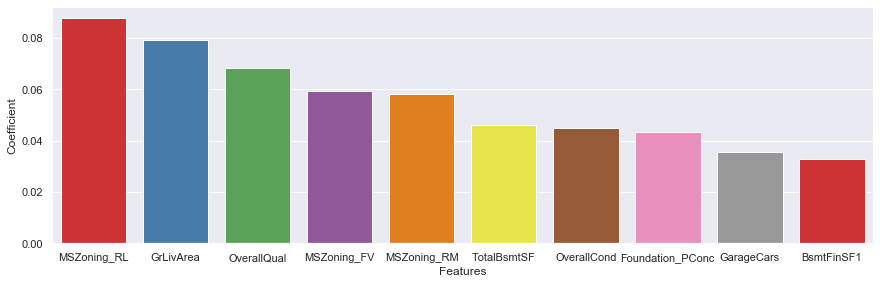

In [87]:
# bar plot to determine the variables that would affect pricing most using ridge regression
plt.figure(figsize=(50,20))
plt.subplot(4,3,1)
sns.barplot(x = 'Features', y='Coefficient', palette='Set1', data = temp1_df)
plt.show()

#### Lasso

In [88]:
lasso = Lasso()

# list of alphas
params = {'alpha': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01]}

# cross validation
folds = 5
lasso_model_cv = GridSearchCV(estimator = lasso,                         
                        param_grid = params, 
                        scoring= 'neg_mean_absolute_error', 
                        cv = folds, 
                        return_train_score=True,
                        verbose = 1)            

lasso_model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 11 candidates, totalling 55 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  55 out of  55 | elapsed:    0.5s finished


GridSearchCV(cv=5, error_score=nan,
             estimator=Lasso(alpha=1.0, copy_X=True, fit_intercept=True,
                             max_iter=1000, normalize=False, positive=False,
                             precompute=False, random_state=None,
                             selection='cyclic', tol=0.0001, warm_start=False),
             iid='deprecated', n_jobs=None,
             param_grid={'alpha': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005,
                                   0.001, 0.002, 0.003, 0.004, 0.005, 0.01]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='neg_mean_absolute_error', verbose=1)

In [89]:
# Print the mean scores
lasso_cv_results = pd.DataFrame(lasso_model_cv.cv_results_)
lasso_cv_results[['param_alpha', 'mean_train_score', 'mean_test_score', 'rank_test_score']].sort_values(by = ['rank_test_score'])

,param_alpha,mean_train_score,mean_test_score,rank_test_score
3,0.0004,-0.078032,-0.084369,1
4,0.0005,-0.078172,-0.084373,2
2,0.0003,-0.077933,-0.084423,3
1,0.0002,-0.077871,-0.084521,4
0,0.0001,-0.077827,-0.084659,5
5,0.001,-0.078855,-0.084718,6
6,0.002,-0.079755,-0.085199,7
7,0.003,-0.080260,-0.085460,8
8,0.004,-0.080756,-0.085879,9
9,0.005,-0.081337,-0.086341,10


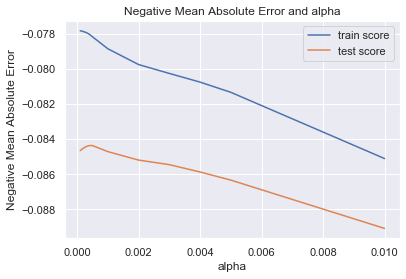

In [90]:
# plotting mean test and train score with alpha 
lasso_cv_results['param_alpha'] = lasso_cv_results['param_alpha'].astype('float64')

# plotting
plt.plot(lasso_cv_results['param_alpha'], lasso_cv_results['mean_train_score'])
plt.plot(lasso_cv_results['param_alpha'], lasso_cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative Mean Absolute Error')

plt.title("Negative Mean Absolute Error and alpha")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

In [91]:
# get the best estimator for lambda
lasso_model_cv.best_estimator_

Lasso(alpha=0.0004, copy_X=True, fit_intercept=True, max_iter=1000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)

In [92]:
# check the coefficient values with lambda = 0.0004

alpha = 0.0004

lasso = Lasso(alpha=alpha)
        
lasso.fit(X_train, y_train) 
lasso.coef_

array([-0.00915998,  0.02165857,  0.06965527,  0.04488911,  0.03336601,
        0.04611213,  0.00319177, -0.        ,  0.10754074,  0.00971068,
        0.01518099,  0.02077453,  0.03633809,  0.00995221, -0.01170117,
       -0.01884216,  0.01427036,  0.01287514,  0.01598228,  0.01832079,
        0.01545907,  0.01631163, -0.01056321,  0.00474103,  0.0149871 ,
        0.07057917,  0.02764822,  0.10983987,  0.07651055,  0.0251925 ,
       -0.0107593 , -0.00795497,  0.02202384, -0.01367778, -0.00996439,
        0.01637499, -0.00955042, -0.00310145,  0.01172176, -0.0294678 ,
       -0.02985886, -0.0006841 , -0.01620654,  0.02493197,  0.01818188,
        0.01800232,  0.04303123,  0.01657175,  0.00631248, -0.00879407])

In [93]:
# Check the mean squared error
mean_squared_error(y_test, lasso.predict(X_test))

0.013556413314276771

In [94]:
# Check the mean squared error
mean_squared_error(y_train, lasso.predict(X_train))

0.0114332064202548

In [95]:
# Print the r2 score for train data
rsquared_train = r2_score(y_train, lasso.predict(X_train))
rsquared_train


0.9187379298150264

In [96]:
# Print the r2 score for test data
rsquared_test = r2_score(y_test, lasso.predict(X_test))
rsquared_test

0.902557982863734

In [97]:
# Getting the shortlisted Features and coefficienst in a dataframe
lasso_df = pd.DataFrame({'Features':X_train.columns, 'Coefficient':lasso.coef_.round(4)})
lasso_df = lasso_df[lasso_df['Coefficient'] != 0.00]
lasso_df.reset_index(drop=True, inplace=True)
lasso_df

,Features,Coefficient
0,MSSubClass,-0.0092
1,LotArea,0.0217
2,OverallQual,0.0697
3,OverallCond,0.0449
4,BsmtFinSF1,0.0334
5,TotalBsmtSF,0.0461
6,1stFlrSF,0.0032
7,GrLivArea,0.1075
8,BsmtFullBath,0.0097
9,HalfBath,0.0152


In [98]:
# Printing the coefficients
lasso_coeff_dict = dict(pd.Series(lasso.coef_, index = X_train.columns))
lasso_coeff_dict

{'MSSubClass': -0.00915998381099718,
 'LotArea': 0.021658568234802264,
 'OverallQual': 0.06965526609648405,
 'OverallCond': 0.044889110314328684,
 'BsmtFinSF1': 0.03336600821268066,
 'TotalBsmtSF': 0.04611213340270227,
 '1stFlrSF': 0.003191765104352835,
 '2ndFlrSF': -0.0,
 'GrLivArea': 0.1075407398883313,
 'BsmtFullBath': 0.009710677163716461,
 'HalfBath': 0.015180991563664582,
 'Fireplaces': 0.020774526969382937,
 'GarageCars': 0.03633809261416283,
 'WoodDeckSF': 0.009952205479949489,
 'IsRemodelled': -0.011701170894639486,
 'BuiltOrRemodelAge': -0.018842161705134964,
 'OldOrNewGarage': 0.014270363551605384,
 'd_BsmtQual': 0.012875138576447887,
 'd_BsmtExposure': 0.015982276173717305,
 'd_HeatingQC': 0.018320789969424323,
 'd_KitchenQual': 0.01545906957733494,
 'd_GarageFinish': 0.016311632317918892,
 'd_BldgType': -0.010563209351042437,
 'd_HouseStyle': 0.004741026631013698,
 'd_SaleCondition': 0.014987101050461162,
 'MSZoning_FV': 0.0705791658811704,
 'MSZoning_RH': 0.02764821503202

#### RFE

In [99]:
# Do an RFE to minimise the features to 15
X_train_lasso = X_train[lasso_df.Features]

lm = LinearRegression()
lm.fit(X_train_lasso, y_train)

# running RFE
rfe = RFE(lm, 15)            
rfe = rfe.fit(X_train_lasso, y_train)

In [100]:
# Method to get the coefficient values
def find(x):
    return lasso_coeff_dict[x]

# Assign top 10 features to a temp dataframe for further display in the bar plot
temp2_df = pd.DataFrame(list(zip( X_train_lasso.columns, rfe.support_, rfe.ranking_)), columns=['Features', 'rfe_support', 'rfe_ranking'])
temp2_df = temp2_df.loc[temp2_df['rfe_support'] == True]
temp2_df.reset_index(drop=True, inplace=True)

temp2_df['Coefficient'] = temp2_df['Features'].apply(find)
temp2_df = temp2_df.sort_values(by=['Coefficient'], ascending=False)
temp2_df = temp2_df.head(10)
temp2_df

,Features,rfe_support,rfe_ranking,Coefficient
11,MSZoning_RL,True,1,0.109840
5,GrLivArea,True,1,0.107541
12,MSZoning_RM,True,1,0.076511
9,MSZoning_FV,True,1,0.070579
1,OverallQual,True,1,0.069655
4,TotalBsmtSF,True,1,0.046112
2,OverallCond,True,1,0.044889
14,Foundation_PConc,True,1,0.043031
7,GarageCars,True,1,0.036338
3,BsmtFinSF1,True,1,0.033366


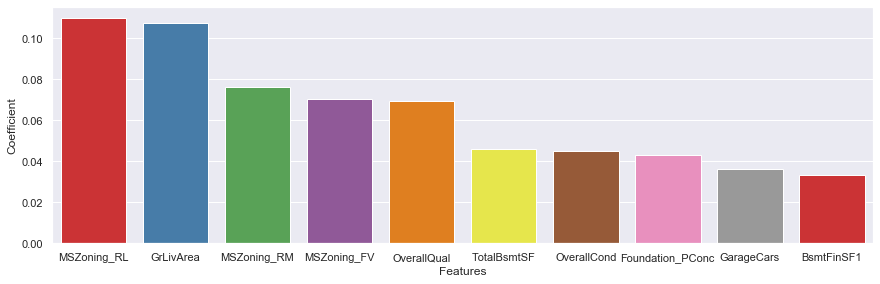

In [101]:
# bar plot to determine the variables that would affect pricing most using Lasso regression

plt.figure(figsize=(50,20))
plt.subplot(4,3,1)
sns.barplot(x = 'Features', y='Coefficient', palette='Set1', data = temp2_df)
plt.show()

### Conclusion :

- Following variables are significant in predicting the price of a house: **MSZoning_RL, GrLivArea, MSZoning_RM, MSZoning_FV, OverallQual, TotalBsmtSF, OverallCond, Foundation_PConc, GarageCars, BsmtFinSF1**

- The optimal value of Lambda in **Ridge** regression (L2 regularization): **10**
- The optimal value of Lambda in **Lasso** regression (L1 regularization): **0.0004**

- The Mean Squared error (**Train**):
    - **Ridge** regression : **0.01149**
    - **Lasso** regression : **0.01143**
- The Mean Squared error (**Test**):
    - **Ridge** regression : **0.01374**
    - **Lasso** regression : **0.01355**

- The **R2score** for **Train** data set:
    - **Ridge** : **0.9182**
    - **Lasso** : **0.9187**

- The **R2score** for **Test** data set:
    - **Ridge** : **0.9012**
    - **Lasso** : **0.9025**

- As per above metrics its evident that R2 score for Lasso is more compared to the Ridge. As well MSE (Mean squared error) for Lasso is less compared to Ridge. 

- Hence, I suggest Lasso regression in this case for the model because not only it provides better metrics compared to Ridge, it also helps in feature selection. 

- We can notice based on Lasso, the features affecting the house price are the Zoning classification(Residential Low Density), Above grade (ground) living area square feet, Zoning classification(Residential Medium Density), Zoning classification(Floating Village Residential) and Overall quality.

- The feature 'BuiltOrRemodelAge' is negatively correlated with the 'Sales Price' of the house, it indicates decrease in 'Sales Price' as 'BuiltOrRemodelAge' increases. Its important to consider this feature while buying the house.

- The features which are positively correlated with 'Sales Price'

- Higer value of positivly correlated featutre tend to incease the house price.

- Its observed that House which fall under Residential Low Density zone are expensive.

- General guidance to Surprise Housing - As market value of House price less than the predicted House price, its good to buy and  if market values is significantly higher (based on the companies decision) than the predicted House price, Its time to sell to make maximum profit!!.
